## Max-Cut as Boolean Quadratic Programming
**IE 802 — Topics in IEOR**


In [ ]:
import itertools, time, random
from collections import defaultdict

import networkx as nx
import numpy as np
import pandas as pd
import pulp
import matplotlib.pyplot as plt

TOL = 1e-6          # violation tolerance
random.seed(42); np.random.seed(42)
plt.rcParams.update({"figure.dpi": 110, "font.size": 10})

In [ ]:
def ekey(i, j):
    return (i, j) if i <= j else (j, i)


def build_model(G, w, binary=False, name="maxcut"):
    '''Padberg BQP linearization.
    binary=False - LP relaxation
    binary=True - exact MILP
    '''
    prob = pulp.LpProblem(name, pulp.LpMaximize)
    xcat = "Binary" if binary else "Continuous"

    x = {i: pulp.LpVariable(f"x_{i}", 0, 1, xcat) for i in G.nodes()}
    y = {ekey(i, j): pulp.LpVariable(f"y_{min(i,j)}_{max(i,j)}", 0, 1, "Continuous")
         for i, j in G.edges()}

    prob += pulp.lpSum(w[e] * (x[e[0]] + x[e[1]] - 2 * y[e]) for e in y)

    for (i, j) in y:
        prob += x[i] + x[j] - y[(i, j)] <= 1, f"C4_{i}_{j}"
        prob += -x[i] + y[(i, j)] <= 0,       f"C5_{i}_{j}"
        prob += -x[j] + y[(i, j)] <= 0,       f"C6_{i}_{j}"
    return prob, x, y


def solve(prob, msg=False, timeLimit=None):
    prob.solve(pulp.PULP_CBC_CMD(msg=msg, timeLimit=timeLimit))
    return pulp.value(prob.objective)


def get_vals(x, y):
    '''Current LP point, plus the derived cut-indicator z_ij = x_i + x_j - 2 y_ij.'''
    xv = {i: (v.varValue or 0.0) for i, v in x.items()}
    yv = {e: (v.varValue or 0.0) for e, v in y.items()}
    zv = {e: xv[e[0]] + xv[e[1]] - 2 * yv[e] for e in yv}
    return xv, yv, zv


def gap_pct(z_bound, z_ip):
    '''Integrality gap in %. Clamped at 0'''
    if not z_ip:
        return 0.0
    g = 100.0 * (z_bound - z_ip) / z_ip
    return 0.0 if abs(g) < 1e-6 else max(g, 0.0)

triangle inequalities

In [ ]:
def triangles(G):
    '''yield each triangle exactly once.'''
    seen = set()
    for u in G.nodes():
        nbrs = list(G.neighbors(u))
        for v, t in itertools.combinations(nbrs, 2):
            if G.has_edge(v, t):
                key = tuple(sorted((u, v, t)))
                if key not in seen:
                    seen.add(key)
                    yield key


def sep_triangles(G, x, y, xv, yv, max_cuts=200):
    '''Return violated T1-T4 constraints, deepest first.'''
    cuts = []
    for (i, j, k) in triangles(G):
        a, b, c = ekey(i, j), ekey(i, k), ekey(j, k)

        v = xv[i] + xv[j] + xv[k] - yv[a] - yv[b] - yv[c] - 1          # T1
        if v > TOL: cuts.append((v, x[i] + x[j] + x[k] - y[a] - y[b] - y[c] <= 1))

        v = -xv[i] + yv[a] + yv[b] - yv[c]                             # T2
        if v > TOL: cuts.append((v, -x[i] + y[a] + y[b] - y[c] <= 0))

        v = -xv[j] + yv[a] - yv[b] + yv[c]                             #T3
        if v > TOL: cuts.append((v, -x[j] + y[a] - y[b] + y[c] <= 0))

        v = -xv[k] - yv[a] + yv[b] + yv[c]                              # T4
        if v > TOL: cuts.append((v, -x[k] - y[a] + y[b] + y[c] <= 0))

    cuts.sort(key=lambda t: -t[0])
    return [c for _, c in cuts[:max_cuts]]

Separation oracle II — clique inequalities

In [ ]:
def sep_cliques(G, x, y, xv, yv, max_cuts=200):
    '''Heuristic separation of Padberg clique inequalities.'''
    cuts, seen = [], set()
    for Q in nx.find_cliques(G):
        if len(Q) < 3:
            continue
        Qs = sorted(Q, key=lambda i: -xv[i])            # greedy: high x* first
        for size in range(3, len(Qs) + 1):
            S = tuple(sorted(Qs[:size]))
            if S in seen:
                continue
            seen.add(S)
            pairs = list(itertools.combinations(S, 2))
            xs = sum(xv[i] for i in S)
            ys = sum(yv[ekey(i, j)] for i, j in pairs)
            for alpha in range(1, size - 1):            # 1 <= alpha <= |Q|-2
                rhs = alpha * (alpha + 1) / 2
                viol = alpha * xs - ys - rhs
                if viol > TOL:
                    expr = (alpha * pulp.lpSum(x[i] for i in S)
                            - pulp.lpSum(y[ekey(i, j)] for i, j in pairs))
                    cuts.append((viol, expr <= rhs))
    cuts.sort(key=lambda t: -t[0])
    return [c for _, c in cuts[:max_cuts]]

Separation oracle III — odd-cycle inequalities

In [ ]:
def sep_odd_cycles(G, x, y, zv, max_cuts=50):
    '''Exact Barahona-Mahjoub separation of odd-cycle inequalities.'''
    H = nx.Graph()
    for i, j in G.edges():
        z = min(max(zv[ekey(i, j)], 0.0), 1.0)   # clip tiny numerical drift
        H.add_edge((i, 0), (j, 0), weight=z)         # e not in F
        H.add_edge((i, 1), (j, 1), weight=z)         # e not in F
        H.add_edge((i, 0), (j, 1), weight=1 - z)     # e in F
        H.add_edge((i, 1), (j, 0), weight=1 - z)     # e in F

    cuts, seen = [], set()
    for s in G.nodes():
        if (s, 0) not in H:                            # isolated vertex
            continue
        try:
            L, path = nx.single_source_dijkstra(H, (s, 0), (s, 1), weight="weight")
        except (nx.NetworkXNoPath, nx.NodeNotFound):
            continue
        if L >= 1 - TOL:
            continue                                   # nothing violated from this root

        F, Cyc, degenerate = [], [], False
        for (a, sa), (b, sb) in zip(path[:-1], path[1:]):
            e = ekey(a, b)
            if e in Cyc:                               # non-simple walk -> skip
                degenerate = True
                break
            Cyc.append(e)
            if sa != sb:
                F.append(e)
        if degenerate or len(F) % 2 == 0:
            continue

        key = (frozenset(F), frozenset(Cyc))
        if key in seen:                                # same cycle found from another root
            continue
        seen.add(key)

        Fs = set(F)
        Rest = [e for e in Cyc if e not in Fs]
        expr = (pulp.lpSum(x[e[0]] + x[e[1]] - 2 * y[e] for e in Fs)
                - pulp.lpSum(x[e[0]] + x[e[1]] - 2 * y[e] for e in Rest))
        cuts.append((1 - L, expr <= len(Fs) - 1))

    cuts.sort(key=lambda t: -t[0])
    return [c for _, c in cuts[:max_cuts]]

The cutting-plane loop

In [ ]:
def cutting_plane(G, w, families=("triangle", "clique", "oddcycle"),
                  max_rounds=30, max_cuts_per_round=200, verbose=False):
    '''Iterative separation. Returns dict with final bound, cut count, per-round history.'''
    t0 = time.time()
    prob, x, y = build_model(G, w, binary=False)
    z = solve(prob)
    hist = [{"round": 0, "stage": "base LP", "bound": z, "cuts_added": 0,
             "cum_cuts": 0, "time": time.time() - t0}]
    total = 0

    for r in range(1, max_rounds + 1):
        xv, yv, zv = get_vals(x, y)
        new = []
        if "triangle" in families:
            new += sep_triangles(G, x, y, xv, yv, max_cuts_per_round)
        if "clique" in families:
            new += sep_cliques(G, x, y, xv, yv, max_cuts_per_round)
        if "oddcycle" in families:
            new += sep_odd_cycles(G, x, y, zv, max_cuts_per_round)

        if not new:
            break                                   # no violated facet -> converged

        for k, c in enumerate(new):
            prob += c, f"cut_r{r}_{k}"
        total += len(new)
        z = solve(prob)
        hist.append({"round": r, "stage": f"round {r}", "bound": z, "cuts_added": len(new),
                     "cum_cuts": total, "time": time.time() - t0})
        if verbose:
            print(f"  round {r:2d}: +{len(new):4d} cuts  ->  LP = {z:.4f}")

    return {"bound": z, "n_cuts": total, "rounds": len(hist) - 1,
            "history": pd.DataFrame(hist), "time": time.time() - t0}


def solve_ip(G, w, timeLimit=None):
    t0 = time.time()
    prob, x, y = build_model(G, w, binary=True)
    z = solve(prob, timeLimit=timeLimit)
    part = {i: int(round(v.varValue or 0)) for i, v in x.items()}
    return z, part, time.time() - t0

Example of 4 nodes

In [ ]:
W4 = {(1, 2): 3, (1, 3): 2, (2, 4): 4, (3, 4): 1, (2, 3): 2}
G4 = nx.Graph(); G4.add_edges_from(W4.keys())
w4 = {ekey(i, j): v for (i, j), v in W4.items()}

z_ip, part, _ = solve_ip(G4, w4)
base, _, _ = build_model(G4, w4); z_base = solve(base)

rows = [("LP relaxation (no cuts)", z_base, gap_pct(z_base, z_ip), 0)]
for fams, label in [(("triangle",),                      "LP + triangle cuts"),
                    (("triangle", "clique"),             "LP + triangle + clique"),
                    (("triangle", "clique", "oddcycle"), "LP + tri + clq + odd-cycle")]:
    r = cutting_plane(G4, w4, families=fams)
    rows.append((label, r["bound"], gap_pct(r["bound"], z_ip), r["n_cuts"]))
rows.append(("IP optimum (exact MILP)", z_ip, 0.0, "-"))

print("Optimal partition S =", sorted(i for i, v in part.items() if v == 1))
display(pd.DataFrame(rows, columns=["Formulation", "Objective", "Gap (%)", "Cuts used"])
        .round({"Objective": 2, "Gap (%)": 2}))

Optimal partition S = [1, 4]


,Formulation,Objective,Gap (%),Cuts used
0,LP relaxation (no cuts),12.0,20.0,0
1,LP + triangle cuts,10.0,0.0,2
2,LP + triangle + clique,10.0,0.0,4
3,LP + tri + clq + odd-cycle,10.0,0.0,6
4,IP optimum (exact MILP),10.0,0.0,-


odd cycles: closing the gap

In [ ]:
rows = []
for n in [5, 7, 9, 11, 13]:
    Cn = nx.cycle_graph(n)
    wn = {ekey(i, j): 1 for i, j in Cn.edges()}
    z_ip, _, _ = solve_ip(Cn, wn)
    b, _, _ = build_model(Cn, wn); z_base = solve(b)
    r_tc = cutting_plane(Cn, wn, families=("triangle", "clique"))
    r_all = cutting_plane(Cn, wn, families=("triangle", "clique", "oddcycle"))
    rows.append([f"C{n}", z_ip, z_base, gap_pct(z_base, z_ip),
                 r_tc["n_cuts"], gap_pct(r_tc["bound"], z_ip),
                 r_all["n_cuts"], gap_pct(r_all["bound"], z_ip)])

df_odd = pd.DataFrame(rows, columns=["Graph", "IP opt", "Base LP", "Base gap %",
                                     "tri+clq cuts", "gap after tri+clq %",
                                     "+odd cuts", "final gap %"])
display(df_odd.round(2))

,Graph,IP opt,Base LP,Base gap %,tri+clq cuts,gap after tri+clq %,+odd cuts,final gap %
0,C5,4.0,5.0,25.00,0,25.00,1,0.0
1,C7,6.0,7.0,16.67,0,16.67,1,0.0
2,C9,8.0,9.0,12.50,0,12.50,1,0.0
3,C11,10.0,11.0,10.00,0,10.00,1,0.0
4,C13,12.0,13.0,8.33,0,8.33,1,0.0


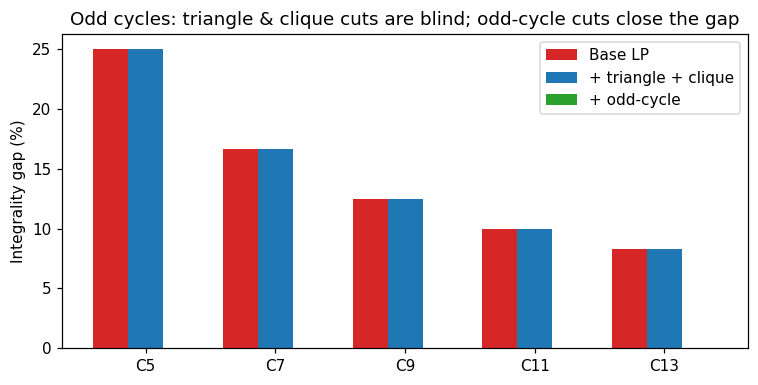

In [ ]:
fig, ax = plt.subplots(figsize=(7, 3.6))
idx = np.arange(len(df_odd)); wdt = 0.27
ax.bar(idx - wdt, df_odd["Base gap %"], wdt, label="Base LP", color="#d62728")
ax.bar(idx, df_odd["gap after tri+clq %"], wdt, label="+ triangle + clique", color="#1f77b4")
ax.bar(idx + wdt, df_odd["final gap %"], wdt, label="+ odd-cycle", color="#2ca02c")
ax.set_xticks(idx); ax.set_xticklabels(df_odd["Graph"])
ax.set_ylabel("Integrality gap (%)")
ax.set_title("Odd cycles: triangle & clique cuts are blind; odd-cycle cuts close the gap")
ax.legend(); plt.tight_layout(); plt.show()

making clique cuts actually fire

In [ ]:
rows = []
for n in [4, 5, 6, 7, 8]:
    Kn = nx.complete_graph(n)
    wn = {ekey(i, j): 1 for i, j in Kn.edges()}
    z_ip, _, _ = solve_ip(Kn, wn)
    b, _, _ = build_model(Kn, wn); z_base = solve(b)
    r_t = cutting_plane(Kn, wn, families=("triangle",))
    r_tc = cutting_plane(Kn, wn, families=("triangle", "clique"))
    rows.append([f"K{n}", z_ip, z_base, gap_pct(z_base, z_ip),
                 r_t["bound"], gap_pct(r_t["bound"], z_ip), r_t["n_cuts"],
                 r_tc["bound"], gap_pct(r_tc["bound"], z_ip), r_tc["n_cuts"]])

df_clq = pd.DataFrame(rows, columns=["Graph", "IP opt", "Base LP", "Base gap %",
                                     "tri bound", "tri gap %", "tri cuts",
                                     "tri+clq bound", "tri+clq gap %", "tri+clq cuts"])
display(df_clq.round(3))

,Graph,IP opt,Base LP,Base gap %,tri bound,tri gap %,tri cuts,tri+clq bound,tri+clq gap %,tri+clq cuts
0,K4,4.0,6.0,50.000,4.000,0.000,4,4.0,0.0,7
1,K5,6.0,10.0,66.667,6.667,11.111,10,6.0,0.0,16
2,K6,9.0,15.0,66.667,10.000,11.111,20,9.0,0.0,30
3,K7,12.0,21.0,75.000,14.000,16.667,35,12.0,0.0,50
4,K8,16.0,28.0,75.000,18.667,16.667,56,16.0,0.0,77


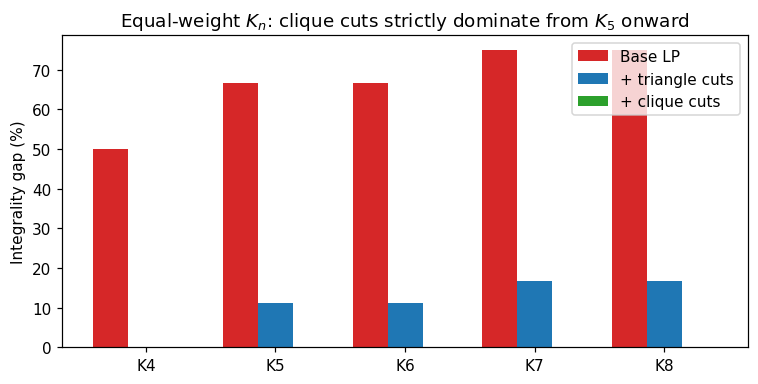

In [ ]:
fig, ax = plt.subplots(figsize=(7, 3.6))
idx = np.arange(len(df_clq)); wdt = 0.27
ax.bar(idx - wdt, df_clq["Base gap %"], wdt, label="Base LP", color="#d62728")
ax.bar(idx, df_clq["tri gap %"], wdt, label="+ triangle cuts", color="#1f77b4")
ax.bar(idx + wdt, df_clq["tri+clq gap %"], wdt, label="+ clique cuts", color="#2ca02c")
ax.set_xticks(idx); ax.set_xticklabels(df_clq["Graph"])
ax.set_ylabel("Integrality gap (%)")
ax.set_title("Equal-weight $K_n$: clique cuts strictly dominate from $K_5$ onward")
ax.legend(); plt.tight_layout(); plt.show()

convergence trace (cuts per round)

  round  1: + 102 cuts  ->  LP = 163.0000
  round  2: +  10 cuts  ->  LP = 162.0000


,round,stage,bound,cuts_added,cum_cuts,time
0,0,base LP,221.0,0,0,0.009
1,1,round 1,163.0,102,102,0.025
2,2,round 2,162.0,10,112,0.040


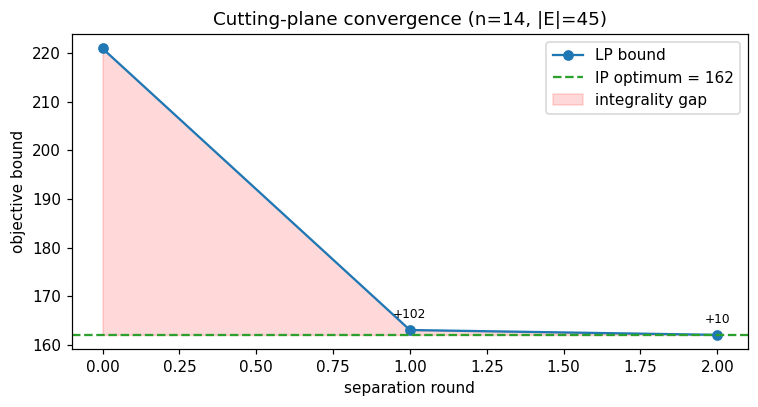

In [ ]:
G_demo = nx.erdos_renyi_graph(14, 0.45, seed=7)
w_demo = {ekey(i, j): random.randint(1, 10) for i, j in G_demo.edges()}
z_ip_demo, _, _ = solve_ip(G_demo, w_demo)
res = cutting_plane(G_demo, w_demo, verbose=True)
display(res["history"].round(3))

h = res["history"]
fig, ax = plt.subplots(figsize=(7, 3.8))
ax.plot(h["round"], h["bound"], "o-", color="#1f77b4", label="LP bound")
ax.axhline(z_ip_demo, ls="--", color="#2ca02c", label=f"IP optimum = {z_ip_demo:.0f}")
ax.fill_between(h["round"], h["bound"], z_ip_demo, alpha=.15, color="red", label="integrality gap")
for _, r in h.iterrows():
    if r["cuts_added"]:
        ax.annotate(f"+{int(r['cuts_added'])}", (r["round"], r["bound"]),
                    textcoords="offset points", xytext=(0, 8), fontsize=8, ha="center")
ax.set_xlabel("separation round"); ax.set_ylabel("objective bound")
ax.set_title(f"Cutting-plane convergence (n=14, |E|={G_demo.number_of_edges()})")
ax.legend(); plt.tight_layout(); plt.show()

integrality gap vs. graph density

In [ ]:
densities = [0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
N_INST, N_VERT = 12, 10
rec = defaultdict(list)

for p in densities:
    g_base, g_t, g_tc, g_all = [], [], [], []
    for s in range(N_INST):
        G = nx.erdos_renyi_graph(N_VERT, p, seed=1000 * s + int(p * 100))
        if G.number_of_edges() == 0:
            continue
        w = {ekey(i, j): random.randint(1, 10) for i, j in G.edges()}
        z_ip, _, _ = solve_ip(G, w)
        if z_ip <= 0:
            continue
        b, _, _ = build_model(G, w)
        g_base.append(gap_pct(solve(b), z_ip))
        g_t.append(gap_pct(cutting_plane(G, w, families=("triangle",))["bound"], z_ip))
        g_tc.append(gap_pct(cutting_plane(G, w, families=("triangle", "clique"))["bound"], z_ip))
        g_all.append(gap_pct(cutting_plane(G, w)["bound"], z_ip))
    rec["p"].append(p)
    rec["base"].append(np.mean(g_base)); rec["tri"].append(np.mean(g_t))
    rec["tri_clq"].append(np.mean(g_tc)); rec["all"].append(np.mean(g_all))
    print(f"p={p:.1f}  base={rec['base'][-1]:6.2f}%  tri={rec['tri'][-1]:5.2f}%  "
          f"tri+clq={rec['tri_clq'][-1]:5.2f}%  +odd={rec['all'][-1]:5.2f}%", flush=True)

df_den = pd.DataFrame(rec)
display(df_den.round(3))

p=0.2  base=  7.98%  tri= 0.87%  tri+clq= 0.87%  +odd= 0.00%
p=0.3  base= 12.49%  tri= 2.33%  tri+clq= 2.33%  +odd= 0.00%
p=0.4  base= 22.90%  tri= 2.69%  tri+clq= 2.69%  +odd= 0.00%
p=0.5  base= 25.30%  tri= 2.34%  tri+clq= 2.34%  +odd= 0.00%
p=0.6  base= 29.95%  tri= 0.35%  tri+clq= 0.35%  +odd= 0.00%
p=0.7  base= 36.24%  tri= 0.16%  tri+clq= 0.11%  +odd= 0.00%
p=0.8  base= 42.14%  tri= 0.05%  tri+clq= 0.03%  +odd= 0.00%
p=0.9  base= 48.42%  tri= 1.12%  tri+clq= 0.00%  +odd= 0.00%


,p,base,tri,tri_clq,all
0,0.2,7.975,0.870,0.870,0.0
1,0.3,12.494,2.327,2.327,0.0
2,0.4,22.901,2.694,2.694,0.0
3,0.5,25.300,2.335,2.335,0.0
4,0.6,29.949,0.347,0.347,0.0
5,0.7,36.241,0.160,0.112,0.0
6,0.8,42.142,0.052,0.033,0.0
7,0.9,48.421,1.117,0.000,0.0


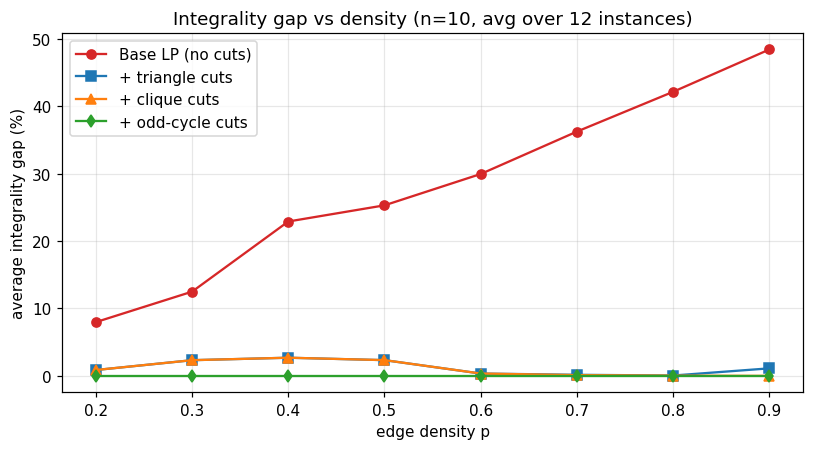

In [ ]:
fig, ax = plt.subplots(figsize=(7.5, 4.2))
ax.plot(df_den["p"], df_den["base"], "o-", color="#d62728", label="Base LP (no cuts)")
ax.plot(df_den["p"], df_den["tri"], "s-", color="#1f77b4", label="+ triangle cuts")
ax.plot(df_den["p"], df_den["tri_clq"], "^-", color="#ff7f0e", label="+ clique cuts")
ax.plot(df_den["p"], df_den["all"], "d-", color="#2ca02c", label="+ odd-cycle cuts")
ax.set_xlabel("edge density p"); ax.set_ylabel("average integrality gap (%)")
ax.set_title(f"Integrality gap vs density (n={N_VERT}, avg over {N_INST} instances)")
ax.legend(); ax.grid(alpha=.3); plt.tight_layout(); plt.show()

graph families

In [ ]:
def make_family():
    fams = {}
    T = nx.random_labeled_tree(10, seed=3); fams["Tree (n=10)"] = T
    fams["Cycle C10 (even)"] = nx.cycle_graph(10)
    fams["Cycle C9 (odd)"] = nx.cycle_graph(9)
    fams["Bipartite K5,5"] = nx.complete_bipartite_graph(5, 5)
    fams["Random n=10 p=0.4"] = nx.erdos_renyi_graph(10, 0.4, seed=11)
    fams["Complete K8"] = nx.complete_graph(8)
    return fams

rows = []
for name, G in make_family().items():
    w = {ekey(i, j): random.randint(1, 10) for i, j in G.edges()}
    z_ip, _, _ = solve_ip(G, w)
    b, _, _ = build_model(G, w); z_base = solve(b)
    r_t = cutting_plane(G, w, families=("triangle",))
    r_tc = cutting_plane(G, w, families=("triangle", "clique"))
    r_all = cutting_plane(G, w)
    rows.append([name, G.number_of_nodes(), G.number_of_edges(), z_ip,
                 gap_pct(z_base, z_ip), gap_pct(r_t["bound"], z_ip),
                 gap_pct(r_tc["bound"], z_ip), gap_pct(r_all["bound"], z_ip), r_all["n_cuts"]])

df_fam = pd.DataFrame(rows, columns=["Family", "n", "|E|", "IP opt", "base gap %",
                                     "tri %", "tri+clq %", "all %", "total cuts"])
display(df_fam.round(2))

,Family,n,|E|,IP opt,base gap %,tri %,tri+clq %,all %,total cuts
0,Tree (n=10),10,9,52.0,0.00,0.00,0.00,0.0,0
1,Cycle C10 (even),10,10,61.0,0.00,0.00,0.00,0.0,0
2,Cycle C9 (odd),9,9,42.0,2.38,2.38,2.38,0.0,1
3,"Bipartite K5,5",10,25,133.0,0.00,0.00,0.00,0.0,0
4,Random n=10 p=0.4,10,16,71.0,18.31,0.00,0.00,0.0,18
5,Complete K8,8,28,98.0,38.78,0.00,0.00,0.0,105


scaling and runtime vs. plain branch-and-bound

In [ ]:
sizes = [12, 16, 20, 24, 28, 32, 36, 40]
rows = []
for n in sizes:
    G = nx.erdos_renyi_graph(n, 0.4, seed=n)
    w = {ekey(i, j): random.randint(1, 10) for i, j in G.edges()}

    z_ip, _, t_ip = solve_ip(G, w, timeLimit=300)          # plain B&B
    r = cutting_plane(G, w, max_rounds=25)                 # LP + separation only

    rows.append([n, G.number_of_edges(), z_ip, t_ip, r["bound"], r["n_cuts"],
                 r["rounds"], r["time"], gap_pct(r["bound"], z_ip), t_ip / max(r["time"], 1e-9)])
    print(f"n={n:3d} |E|={G.number_of_edges():4d} | B&B {t_ip:7.2f}s | "
          f"cuts {r['time']:6.2f}s ({r['n_cuts']} cuts, {r['rounds']} rounds) | "
          f"resid gap {rows[-1][8]:.2f}% | speedup {rows[-1][9]:5.1f}x", flush=True)

df_scale = pd.DataFrame(rows, columns=["n", "|E|", "IP opt", "B&B time (s)", "LP+cuts bound",
                                       "cuts", "rounds", "cut time (s)", "resid gap %", "speedup x"])
display(df_scale.round(3))

n= 12 |E|=  27 | B&B    0.07s | cuts   0.02s (36 cuts, 1 rounds) | resid gap 0.00% | speedup   3.4x
n= 16 |E|=  54 | B&B    0.63s | cuts   0.05s (131 cuts, 2 rounds) | resid gap 0.00% | speedup  13.3x
n= 20 |E|=  92 | B&B    1.09s | cuts   0.16s (278 cuts, 1 rounds) | resid gap 0.00% | speedup   7.0x
n= 24 |E|= 107 | B&B    1.49s | cuts   0.12s (288 cuts, 3 rounds) | resid gap 0.00% | speedup  12.5x
n= 28 |E|= 168 | B&B    7.83s | cuts   0.47s (687 cuts, 4 rounds) | resid gap 0.00% | speedup  16.8x
n= 32 |E|= 207 | B&B   15.95s | cuts   0.94s (844 cuts, 6 rounds) | resid gap 0.00% | speedup  16.9x
n= 36 |E|= 237 | B&B   34.76s | cuts   3.86s (1132 cuts, 14 rounds) | resid gap 0.12% | speedup   9.0x
n= 40 |E|= 312 | B&B   66.96s | cuts   1.95s (1313 cuts, 5 rounds) | resid gap 0.00% | speedup  34.4x


,n,|E|,IP opt,B&B time (s),LP+cuts bound,cuts,rounds,cut time (s),resid gap %,speedup x
0,12,27,135.0,0.065,135.000,36,1,0.019,0.00,3.388
1,16,54,219.0,0.635,219.000,131,2,0.048,0.00,13.342
2,20,92,377.0,1.090,377.000,278,1,0.155,0.00,7.024
3,24,107,440.0,1.490,440.000,288,3,0.120,0.00,12.456
4,28,168,687.0,7.831,687.000,687,4,0.465,0.00,16.833
5,32,207,821.0,15.955,821.000,844,6,0.943,0.00,16.914
6,36,237,838.0,34.760,839.004,1132,14,3.862,0.12,9.000
7,40,312,1112.0,66.963,1112.000,1313,5,1.947,0.00,34.391


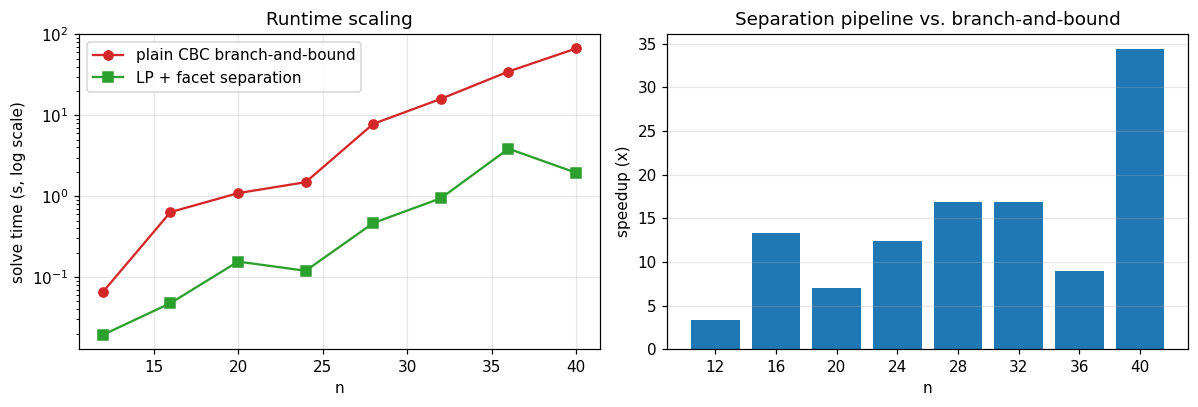

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
axes[0].semilogy(df_scale["n"], df_scale["B&B time (s)"], "o-", color="#d62728",
                 label="plain CBC branch-and-bound")
axes[0].semilogy(df_scale["n"], df_scale["cut time (s)"], "s-", color="#2ca02c",
                 label="LP + facet separation")
axes[0].set_xlabel("n"); axes[0].set_ylabel("solve time (s, log scale)")
axes[0].set_title("Runtime scaling"); axes[0].legend(); axes[0].grid(alpha=.3)

axes[1].bar(df_scale["n"].astype(str), df_scale["speedup x"], color="#1f77b4")
axes[1].set_xlabel("n"); axes[1].set_ylabel("speedup (x)")
axes[1].set_title("Separation pipeline vs. branch-and-bound"); axes[1].grid(alpha=.3, axis="y")
plt.tight_layout(); plt.show()

Summary

In [ ]:
print("=" * 74)
print("SUMMARY OF RESULTS")
print("=" * 74)
print(f"1. Odd-cycle separation closed the C9/C11 gap "
      f"({df_odd.loc[df_odd.Graph=='C9','Base gap %'].iat[0]:.1f}% -> "
      f"{df_odd.loc[df_odd.Graph=='C9','final gap %'].iat[0]:.1f}% on C9); "
      f"triangle+clique oracles found 0 cuts there.")
print(f"2. Clique cuts strictly dominate from K5 onward: on K8, triangle cuts stall at "
      f"{df_clq.loc[df_clq.Graph=='K8','tri gap %'].iat[0]:.1f}% -> clique cuts reach "
      f"{df_clq.loc[df_clq.Graph=='K8','tri+clq gap %'].iat[0]:.1f}%.")
print(f"3. Average base-LP gap across densities: {df_den['base'].mean():.1f}% -> "
      f"{df_den['all'].mean():.2f}% after full separation "
      f"({100*(1-df_den['all'].mean()/max(df_den['base'].mean(),1e-9)):.1f}% of gap closed).")
print(f"4. Max speedup vs plain CBC branch-and-bound: {df_scale['speedup x'].max():.1f}x "
      f"at n={int(df_scale.loc[df_scale['speedup x'].idxmax(),'n'])}.")
print("=" * 74)

SUMMARY OF RESULTS
1. Odd-cycle separation closed the C9/C11 gap (12.5% -> 0.0% on C9); triangle+clique oracles found 0 cuts there.
2. Clique cuts strictly dominate from K5 onward: on K8, triangle cuts stall at 16.7% -> clique cuts reach 0.0%.
3. Average base-LP gap across densities: 28.2% -> 0.00% after full separation (100.0% of gap closed).
4. Max speedup vs plain CBC branch-and-bound: 34.4x at n=40.
